<a href="https://colab.research.google.com/github/agie-nugroho/customer-order-analysis-/blob/main/customer_order_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# PRAKTIK DASAR STATISTIK PADA PYTHON

In [2]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
# Import DataFrame
df = pd.DataFrame({
    "Order_Amount": [250, 400, 150, 500, 350, 420, 310, 280, 390, 450],  # nominal pesanan
    "Num_Items": [3, 5, 2, 6, 4, 5, 4, 3, 5, 6],                         # jumlah item
    "Customer_Age": [25, 34, 22, 45, 31, 37, 29, 28, 33, 40],            # umur pelanggan
    "Discount": [5, 10, 0, 15, 10, 12, 8, 5, 10, 15],                    # diskon %
    "Delivery_Time": [30, 45, 20, 60, 40, 50, 35, 30, 45, 55]            # waktu pengiriman (menit)
})

df

,Order_Amount,Num_Items,Customer_Age,Discount,Delivery_Time
0,250,3,25,5,30
1,400,5,34,10,45
2,150,2,22,0,20
3,500,6,45,15,60
4,350,4,31,10,40
5,420,5,37,12,50
6,310,4,29,8,35
7,280,3,28,5,30
8,390,5,33,10,45
9,450,6,40,15,55


In [19]:
# 2. MEASURING CENTRAL TENDENCY (UKURAN PEMUSATAN DATA)

# Mean (Rata-rata data)
mean_values = df.mean()
print("Nilai mean nya adalah:\n", mean_values)

print("\n")

# Median (Nilai tengah)
median_values = df.median()
print("Nilai tengah nya adalah:\n", median_values)

# print("\n")

# Modus / Mode (Nilai terbanyak muncul)
mode_values = df.mode().iloc[0]  # modus pertama tiap kolom
print("\nNilai modusnya adalah:\n", mode_values)

Nilai mean nya adalah:
 Order_Amount     350.0
Num_Items          4.3
Customer_Age      32.4
Discount           9.0
Delivery_Time     41.0
dtype: float64


Nilai tengah nya adalah:
 Order_Amount     370.0
Num_Items          4.5
Customer_Age      32.0
Discount          10.0
Delivery_Time     42.5
dtype: float64

Nilai modusnya adalah:
 Order_Amount     150.0
Num_Items          5.0
Customer_Age      22.0
Discount          10.0
Delivery_Time     30.0
Name: 0, dtype: float64


In [27]:
# MEASURING DISPERSION (UKURAN PENYEBARAN DATA)
# RANGE = MAX - MIN
# IQR = Q3 - Q1
# VARIANCE = RATA RATA KUADRAT DEVIASI DARI MEAN
# STD = AKAR VARIANCE

# RANGE
range_values = df.max() - df.min()
print("\nNilai range nya adalah:\n", range_values)

# IQR
iqrs_values = df.quantile(3/4) - df.quantile(1/4)         # dengan manual
print(iqrs_values)
iqr_values = df.apply(stats.iqr)    # IQR
print("\nNilai dari IQR adalah:\n", iqr_values)           # dengan stats

# VARIANCE
variance_values = df.var()
print("\nNilai dari variance data adalah:\n", variance_values)

# ST DEVIATION
std_values = df.std()
print("\nNilai dari standar deviasi adalah:\n", std_values)



Nilai range nya adalah:
 Order_Amount     350
Num_Items          4
Customer_Age      23
Discount          15
Delivery_Time     40
dtype: int64
Order_Amount     127.50
Num_Items          1.75
Customer_Age       8.00
Discount           5.75
Delivery_Time     17.50
dtype: float64

Nilai dari IQR adalah:
 Order_Amount     127.50
Num_Items          1.75
Customer_Age       8.00
Discount           5.75
Delivery_Time     17.50
dtype: float64

Nilai dari variance data adalah:
 Order_Amount     10888.888889
Num_Items            1.788889
Customer_Age        48.488889
Discount            22.000000
Delivery_Time      154.444444
dtype: float64

Nilai dari standar deviasi adalah:
 Order_Amount     104.349839
Num_Items          1.337494
Customer_Age       6.963396
Discount           4.690416
Delivery_Time     12.427568
dtype: float64


In [40]:
# MEASURING ASYMMETICAL (SKEWWNESS / DISTRIBUTION)
# SIMETRIS -> MEAN = MEDIAN = MODE
# DISTIBUSI RIGHT-SKEWED -> MIRING KANAN -> MEAN > MEDIAN & MODE -> MAJOR DI KIRI
# DISTRIBUSI LEFT-SKEWED -> MIRING KIRI -> MEAN < MEDIAN & MODE -> MAJOR DI KANAN

# Skewness
skewness_values = df.skew()
print("\nSkewness:\n", skewness_values)

# interpretasi distribusi tiap kolom
for col in df.columns:
  if skewness_values[col] > 0:
    print(f"{col}:  {skewness_values[col]} Right-skewed")
  elif skewness_values[col] < 0:
    print(f"{col}: {skewness_values[col]} Left-skewed")
  else:
    print(f"{col}: {skewness_values[col]}Symmetrical")


Skewness:
 Order_Amount    -0.550053
Num_Items       -0.334360
Customer_Age     0.363496
Discount        -0.533002
Delivery_Time   -0.121568
dtype: float64
Order_Amount: -0.5500531650190809 Left-skewed
Num_Items: -0.33436047775252425 Left-skewed
Customer_Age:  0.3634956188355614 Right-skewed
Discount: -0.533001790889026 Left-skewed
Delivery_Time: -0.12156774168887291 Left-skewed


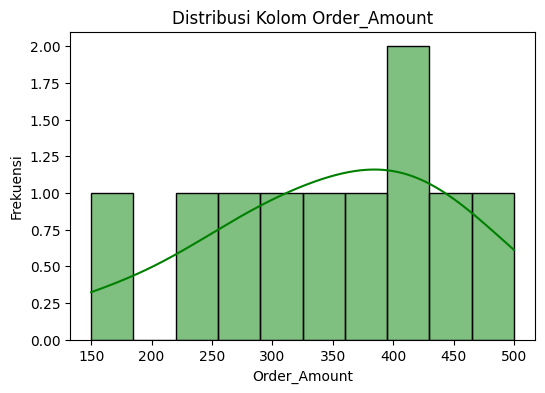

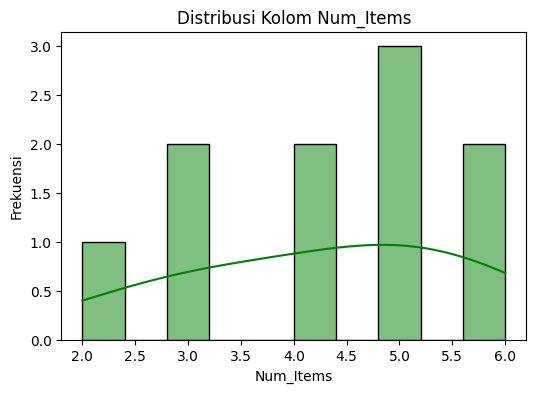

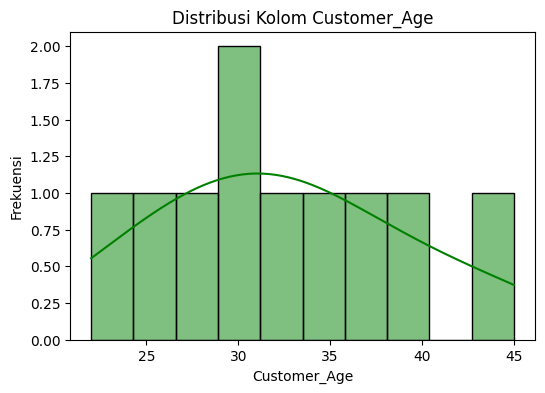

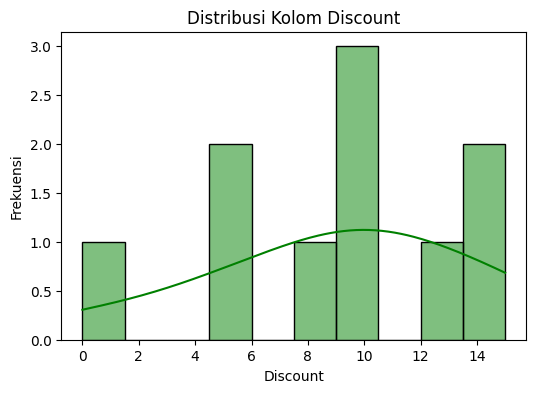

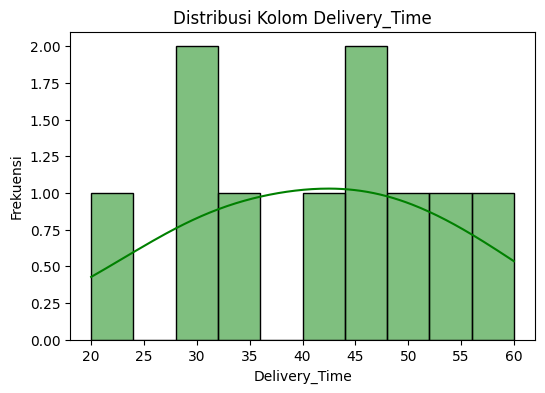

In [57]:
# VISUALISASI
# Grafik distribusi tiap kolom
for col in df.columns:
  plt.figure(figsize=(6,4))
  # kde ->  kernel density estimate
  sns.histplot(df[col], kde = 1, color="green", bins=10)  # histogram + density plot
  plt.title(f"Distribusi Kolom {col}")
  plt.xlabel(col)
  plt.ylabel("Frekuensi")
  plt.show()

In [61]:
# DATA RELATIONSHIP
# CORRELATION -> ARAH HUBUNGAN LINIER
# COVARIANCE -> VARIABILITAS BERSAMA ANTAR 2 VARIABEL

# CORRELATION MATRIX  (hubungan linier antar kolom)
correlation = df.corr()
print("\nCorrelation:\n", correlation)

# covariance matrix (varibilitas bersama antar kolom)
covariance = df.cov()
print("\nCovariance:\n", covariance)


Correlation:
                Order_Amount  Num_Items  Customer_Age  Discount  Delivery_Time
Order_Amount       1.000000   0.979217      0.969469  0.980704       0.989604
Num_Items          0.979217   1.000000      0.952023  0.974131       0.982646
Customer_Age       0.969469   0.952023      1.000000  0.952540       0.983510
Discount           0.980704   0.974131      0.952540  1.000000       0.981674
Delivery_Time      0.989604   0.982646      0.983510  0.981674       1.000000

Covariance:
                Order_Amount   Num_Items  Customer_Age    Discount  \
Order_Amount   10888.888889  136.666667    704.444444  480.000000   
Num_Items        136.666667    1.788889      8.866667    6.111111   
Customer_Age     704.444444    8.866667     48.488889   31.111111   
Discount         480.000000    6.111111     31.111111   22.000000   
Delivery_Time   1283.333333   16.333333     85.111111   57.222222   

               Delivery_Time  
Order_Amount     1283.333333  
Num_Items          16.3333

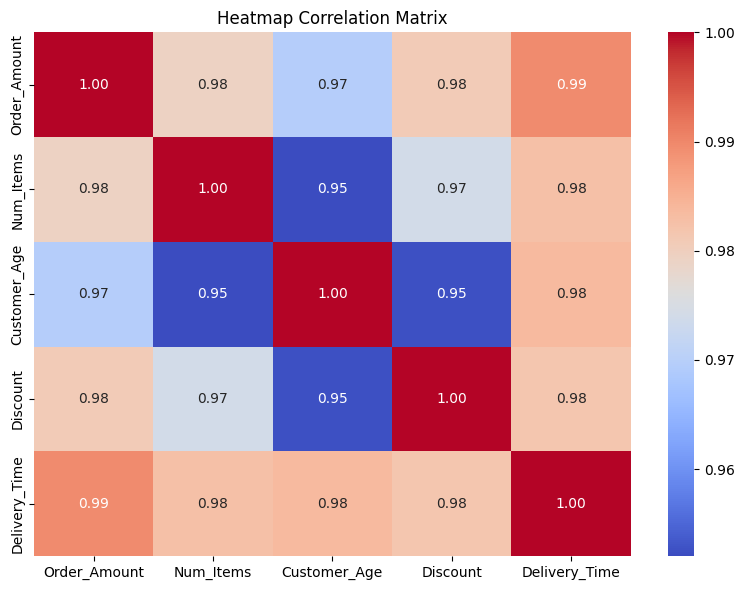

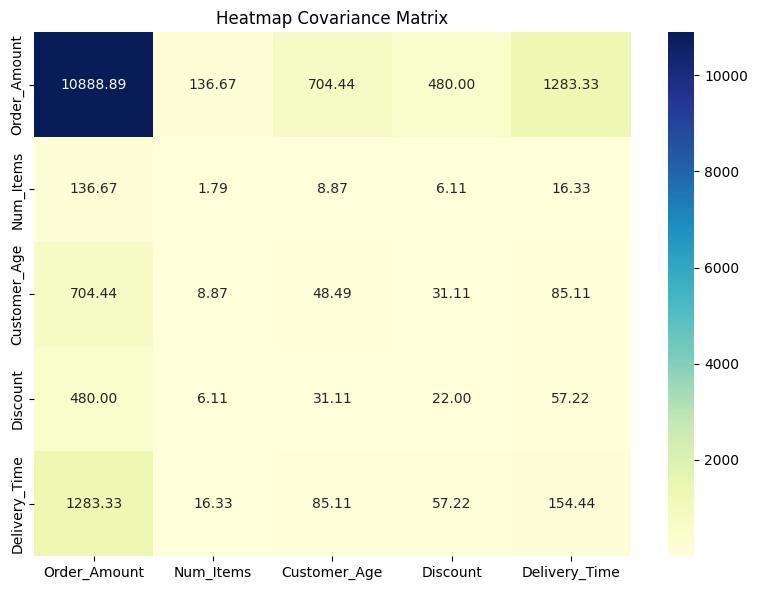

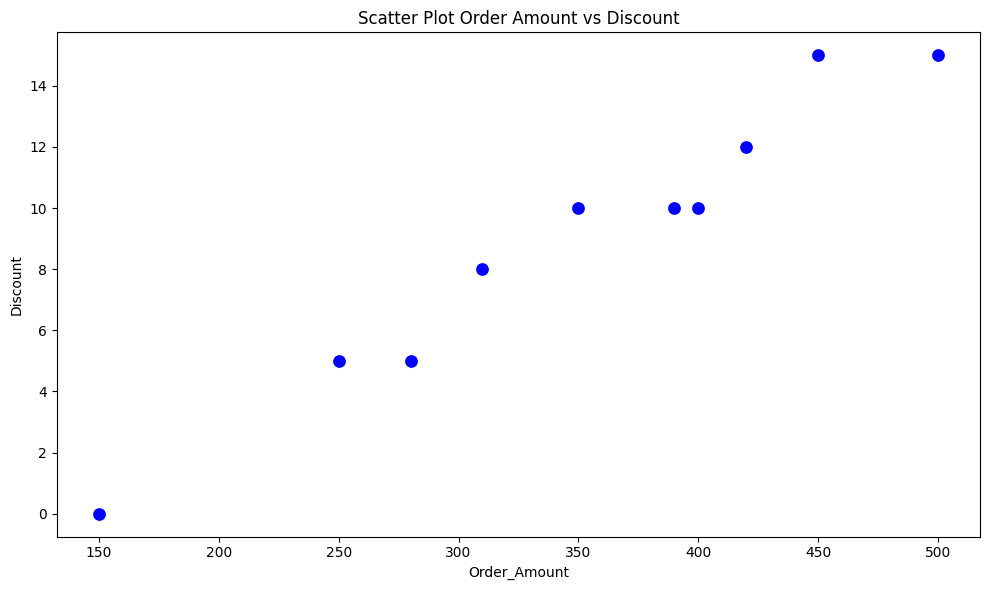

In [85]:
# VISUALISASI RELATIONSHIP

# Heat map Correlation
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap = "coolwarm", fmt = ".2f") # annot ->  menampilkan angka
plt.title("Heatmap Correlation Matrix")
plt.tight_layout()
plt.show()

# Heatmap covariance
plt.figure(figsize=(8,6))
sns.heatmap(covariance, annot=True, cmap="YlGnBu",fmt=".2f")
plt.title("Heatmap Covariance Matrix")
plt.tight_layout()
plt.show()


# Scatter plot untuk order_amount vs discount (titik biru)
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Order_Amount", y="Discount", color="blue", s=100)

plt.title("Scatter Plot Order Amount vs Discount")
plt.tight_layout()
plt.show()